<a href="https://colab.research.google.com/github/smitp2705/PR1_supervised/blob/main/House_Price_Regression_Project_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction — Regression & Gradient Descent

## Part A: Conceptual Understanding (Theory)

### 1. What is Supervised Learning?
Supervised learning is a category of machine learning where a model learns from a
dataset that already contains the correct answers (labels). Every training example
pairs some input features with a known output, and the algorithm's job is to learn the
mapping between them well enough to predict outputs for new, unseen inputs. Linear
Regression, Logistic Regression, Decision Trees, and SVMs all fall under this umbrella.

### 2. Regression vs Classification
| Aspect | Regression | Classification |
|---|---|---|
| Output type | Continuous number | Discrete category/label |
| Goal | Estimate a quantity | Assign a class |
| Typical use | Forecasting, pricing | Detection, tagging |
| Example | Predicting house price | Detecting spam email |

### 3. Simple Linear Regression
Simple Linear Regression models the relationship between exactly one input variable
and one output variable by fitting a straight line:

**Y = m·X + c**

`m` (slope) tells us how much Y changes per unit change in X, and `c` (intercept) is
the value of Y when X is zero. It's the most basic regression tool, useful when one
variable clearly dominates the relationship.

### 4. Assumptions Behind Linear Regression
1. **Linearity** — the relationship between inputs and output is approximately a straight line.
2. **Independence** — each observation is unrelated to the others.
3. **Homoscedasticity** — the spread of residuals stays roughly constant across predictions.
4. **Normality of residuals** — the errors are roughly normally distributed.
5. **No/low multicollinearity** — input features shouldn't be strongly correlated with each other.

### 5. Bias–Variance Trade-off
Every model has to balance two sources of error. **Bias** is error from oversimplifying
the problem (the model can't capture real patterns). **Variance** is error from being
overly sensitive to the specific training data (the model memorizes noise). Low bias +
low variance is the goal, but pushing one down often pushes the other up — hence a
"trade-off." The best model finds a sweet spot that generalizes well to new data.

### 6. Overfitting & Underfitting
**Overfitting** happens when a model is too flexible and starts fitting random noise
in the training data — it looks great on training data but performs poorly on new
data. A very high-degree polynomial curve wiggling to touch every training point is a
classic example.

**Underfitting** happens when a model is too rigid to capture the real pattern —
performance is weak on *both* training and test data. Fitting a straight line to a
clearly curved relationship is a typical example.

**In this project:** predicting house price from area alone using a straight line
will underfit (price depends on much more than area), while an overly complex
polynomial fit across many features risks overfitting. The sweet spot is a model
complex enough to use the real drivers of price without chasing noise.

---
## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)

## Part B: Dataset Understanding & Preparation

In [ ]:
house_df = pd.read_csv("/content/house_price.csv.csv")
house_df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [ ]:
print(house_df.shape)
house_df.dtypes

(4200, 12)


,0
house_id,int64
area_sqft,int64
bedrooms,int64
bathrooms,int64
location_score,float64
age_years,int64
distance_city_km,float64
lot_size_sqft,int64
has_garage,int64
has_pool,int64


In [ ]:
house_df.describe()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


In [ ]:
house_df.isnull().sum()

,0
house_id,0
area_sqft,0
bedrooms,0
bathrooms,0
location_score,0
age_years,0
distance_city_km,0
lot_size_sqft,0
has_garage,0
has_pool,0


In [ ]:
features = house_df.drop(columns=["house_id", "house_price_inr"])
target = house_df["house_price_inr"]

print("Independent variables ->", list(features.columns))
print("Dependent variable   ->", target.name)

Independent variables -> ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago']
Dependent variable   -> house_price_inr


### Visualizing Feature–Price Relationships

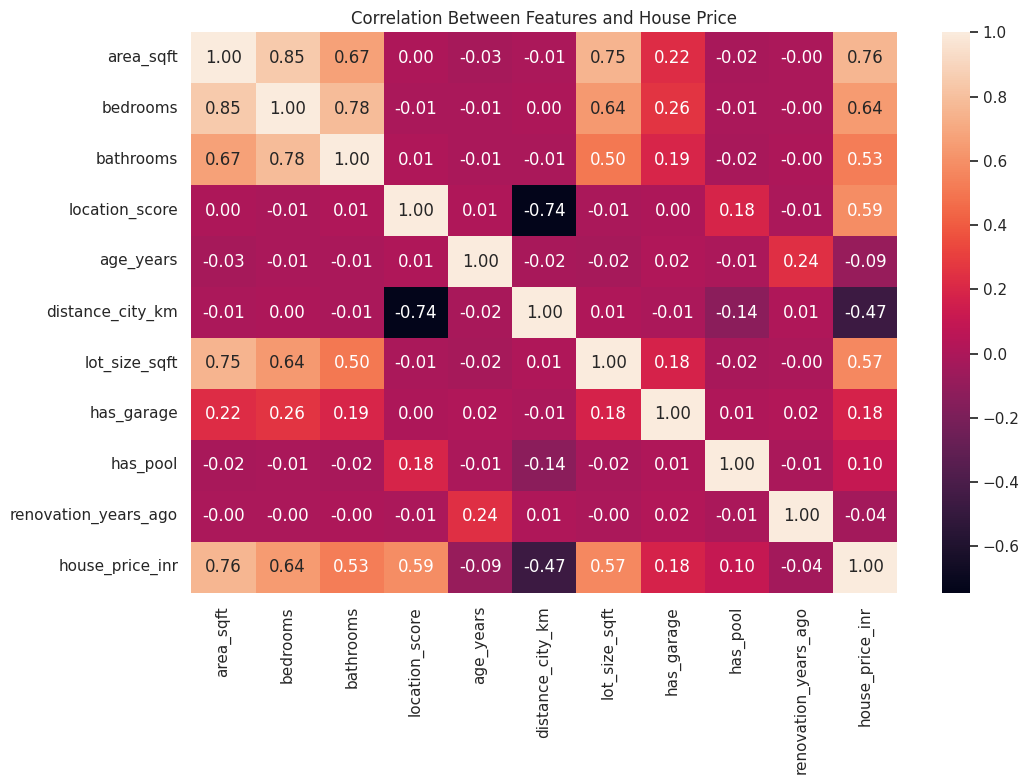

In [ ]:
plt.figure(figsize=(11, 8))
sns.heatmap(house_df.drop(columns="house_id").corr(numeric_only=True),
            annot=True, fmt=".2f")
plt.title("Correlation Between Features and House Price")
plt.tight_layout()
plt.show()

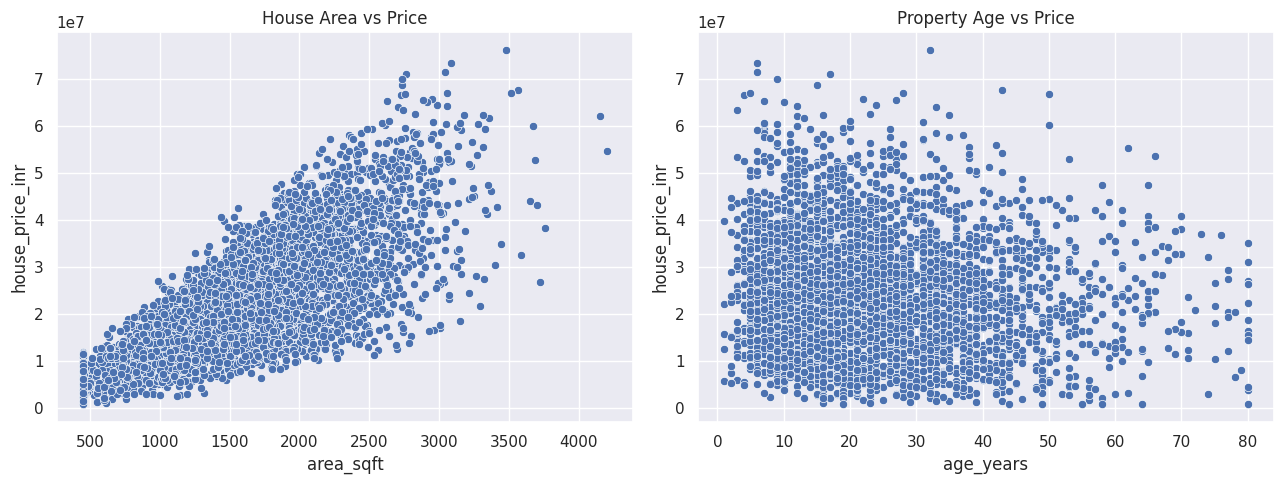

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=house_df["area_sqft"], y=house_df["house_price_inr"], ax=ax[0])
ax[0].set_title("House Area vs Price")

sns.scatterplot(x=house_df["age_years"], y=house_df["house_price_inr"], ax=ax[1])
ax[1].set_title("Property Age vs Price")
plt.tight_layout()
plt.show()

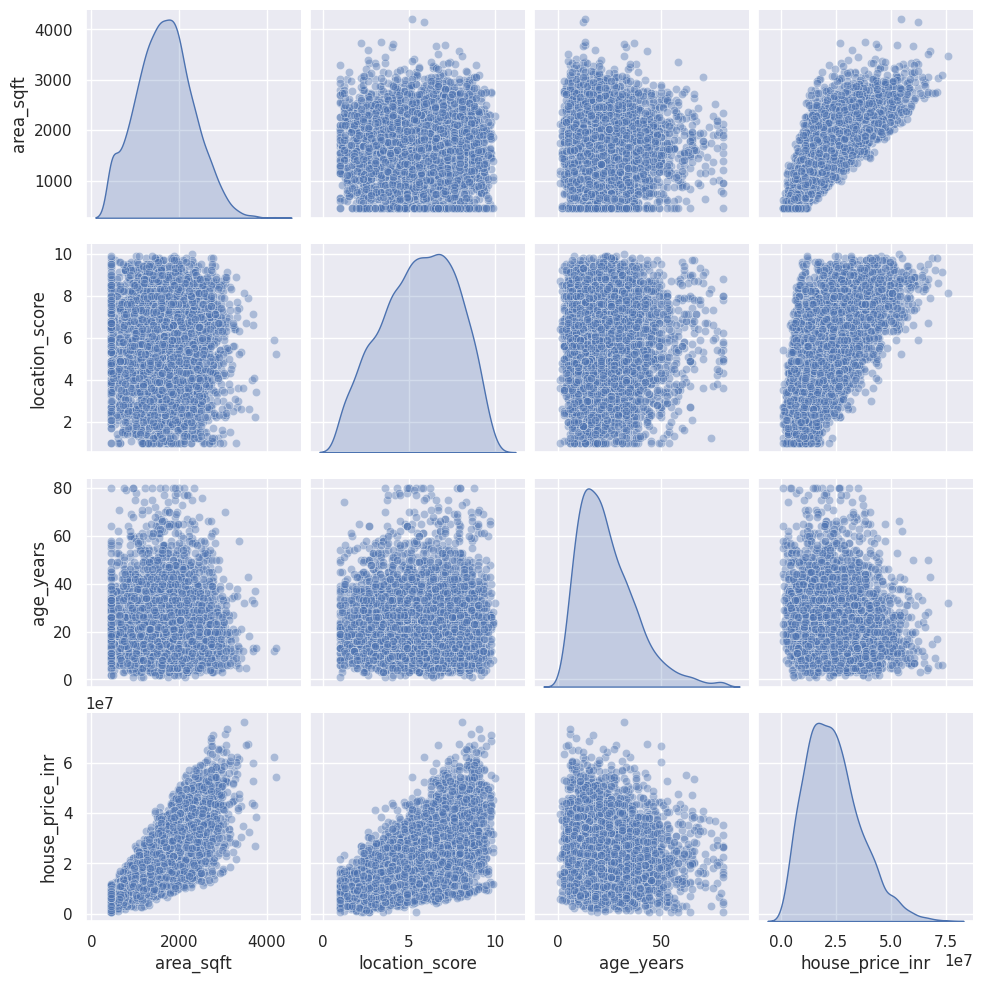

In [ ]:
sns.pairplot(house_df[["area_sqft", "location_score", "age_years", "house_price_inr"]],
             diag_kind="kde", plot_kws={"alpha": 0.4})
plt.show()

### Train/Test Split (used for the full-feature models)

In [ ]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    features, target, test_size=0.2, random_state=42
)
print("Train rows:", X_train_full.shape[0], "| Test rows:", X_test_full.shape[0])

Train rows: 3360 | Test rows: 840


---
## Part C: Simple Linear Regression (Area → Price)

In [ ]:
X_area = house_df[["area_sqft"]]

X_train_sim, X_test_sim, y_train_sim, y_test_sim = train_test_split(
    X_area, target, test_size=0.2, random_state=42
)

lr_simple = LinearRegression()
lr_simple.fit(X_train_sim, y_train_sim)
pred_simple = lr_simple.predict(X_test_sim)

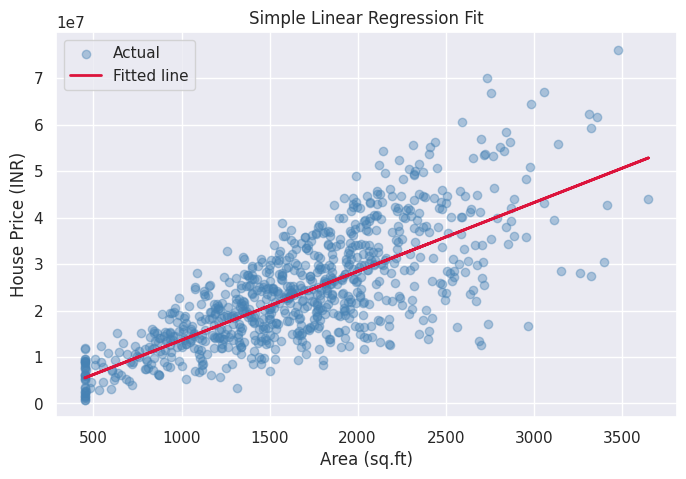

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test_sim, y_test_sim, alpha=0.4, color="steelblue", label="Actual")
plt.plot(X_test_sim, pred_simple, color="crimson", linewidth=2, label="Fitted line")
plt.xlabel("Area (sq.ft)")
plt.ylabel("House Price (INR)")
plt.title("Simple Linear Regression Fit")
plt.legend()
plt.show()

In [ ]:
print("Slope (m):", lr_simple.coef_[0])
print("Intercept (c):", lr_simple.intercept_)

Slope (m): 14788.306111307542
Intercept (c): -1163519.1764186136


The slope tells us how much price rises for every extra square foot of area, and the
intercept is just the mathematical baseline of the line — it has no direct real-world
meaning since a house can't have zero area.

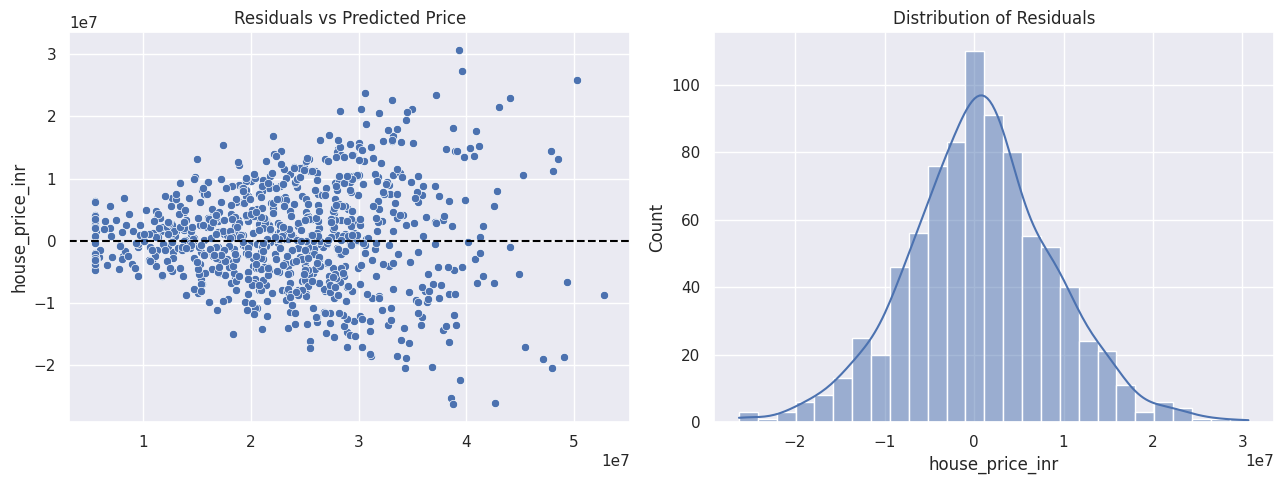

In [ ]:
residuals_sim = y_test_sim - pred_simple

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=pred_simple, y=residuals_sim, ax=ax[0])
ax[0].axhline(0, color="black", linestyle="--")
ax[0].set_title("Residuals vs Predicted Price")

sns.histplot(residuals_sim, kde=True, ax=ax[1])
ax[1].set_title("Distribution of Residuals")
plt.tight_layout()
plt.show()

The residuals scatter without a strong shape, roughly centered at zero, and the
histogram looks close to bell-shaped — reasonable (if imperfect) support for the
linearity, homoscedasticity, and normality assumptions.

## Part D: Evaluating the Simple Model

In [ ]:
def regression_report(y_true, y_pred, n_features, label):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    print(f"[{label}]")
    print(f"  MSE          : {mse:,.2f}")
    print(f"  MAE          : {mae:,.2f}")
    print(f"  RMSE         : {rmse:,.2f}")
    print(f"  R2           : {r2:.4f}")
    print(f"  Adjusted R2  : {adj_r2:.4f}\n")
    return dict(model=label, MSE=mse, MAE=mae, RMSE=rmse, R2=r2, Adj_R2=adj_r2)

scoreboard = []
scoreboard.append(regression_report(y_test_sim, pred_simple, 1, "Simple LR (area only)"))

[Simple LR (area only)]
  MSE          : 66,989,260,021,849.47
  MAE          : 6,294,593.70
  RMSE         : 8,184,696.70
  R2           : 0.5625
  Adjusted R2  : 0.5620



- **MSE** squares the errors so bigger mistakes are punished harder — useful for
  optimization but not intuitive in real units.
- **MAE** is the plain average error in rupees — easy to explain to a non-technical audience.
- **RMSE** brings MSE back into rupee units while still weighting large errors more than MAE.
- **R²** is the fraction of price variation the model explains.
- **Adjusted R²** corrects R² for the number of predictors, so it won't look better
  just because more (possibly useless) features were added.

---
## Part E: Multiple Linear Regression (All Features)

In [ ]:
lr_multi = LinearRegression()
lr_multi.fit(X_train_full, y_train_full)
pred_multi = lr_multi.predict(X_test_full)

scoreboard.append(regression_report(y_test_full, pred_multi, X_train_full.shape[1],
                                     "Multiple LR (all features)"))

[Multiple LR (all features)]
  MSE          : 12,592,918,884,127.62
  MAE          : 2,604,991.41
  RMSE         : 3,548,650.29
  R2           : 0.9178
  Adjusted R2  : 0.9168



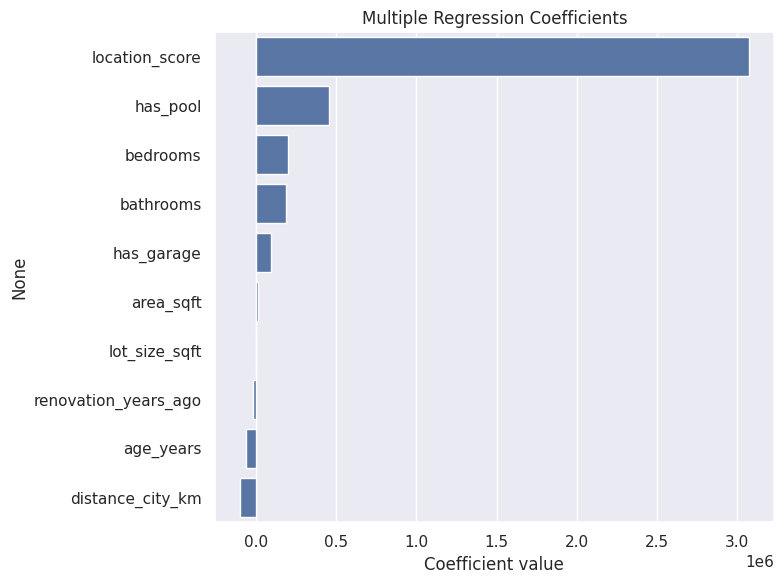

In [ ]:
coef_table = pd.Series(lr_multi.coef_, index=features.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=coef_table.values, y=coef_table.index)
plt.title("Multiple Regression Coefficients")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

Multiple Linear Regression beats the single-feature model because house price is
influenced by many things at once — location, age, bathrooms, distance from the city,
and more. Feeding the model that extra information lets it explain a larger share of
the price variation, which is why RMSE drops and R² (and, importantly, **Adjusted**
R²) both rise.

---
## Part F: Polynomial Regression (Degree 2)

In [ ]:
poly_transform = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_transform.fit_transform(features)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, target, test_size=0.2, random_state=42
)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train_poly)
pred_poly = lr_poly.predict(X_test_poly)

scoreboard.append(regression_report(y_test_poly, pred_poly, X_train_poly.shape[1],
                                     "Polynomial LR (degree 2)"))

[Polynomial LR (degree 2)]
  MSE          : 5,139,490,891,528.84
  MAE          : 1,656,922.80
  RMSE         : 2,267,044.53
  R2           : 0.9664
  Adjusted R2  : 0.9636



In [ ]:
score_df = pd.DataFrame(scoreboard)[["model", "MSE", "MAE", "RMSE", "R2", "Adj_R2"]]
score_df

,model,MSE,MAE,RMSE,R2,Adj_R2
0,Simple LR (area only),6.698926e+13,6.294594e+06,8.184697e+06,0.562520,0.561998
1,Multiple LR (all features),1.259292e+13,2.604991e+06,3.548650e+06,0.917761,0.916769
2,Polynomial LR (degree 2),5.139491e+12,1.656923e+06,2.267045e+06,0.966436,0.963617


Polynomial Regression pushes R² up a bit further by letting the model bend around
curved relationships in the data (e.g., interactions between features) that a purely
linear model can't represent. The gain has to be checked against the training score
though — a much bigger jump on train than on test would flag overfitting.

---
## Part G: Gradient Descent From Scratch

Gradient Descent optimizes the weight (`w`) and bias (`b`) of a line by repeatedly
nudging them in the direction that reduces the Mean Squared Error, controlled by a
learning rate. Here we standardize the area feature first so the algorithm converges
smoothly with a normal-sized learning rate (the raw rupee-scale feature would need an
extremely tiny learning rate otherwise).

In [ ]:
area_vals = house_df["area_sqft"].values.astype(float)
price_vals = house_df["house_price_inr"].values.astype(float)

area_mean, area_std = area_vals.mean(), area_vals.std()
price_mean, price_std = price_vals.mean(), price_vals.std()

area_scaled = (area_vals - area_mean) / area_std
price_scaled = (price_vals - price_mean) / price_std

w, b = 0.0, 0.0
learning_rate = 0.05
n_epochs = 500
n_points = len(area_scaled)
cost_log = []

for epoch in range(n_epochs):
    preds = w * area_scaled + b
    error = preds - price_scaled

    grad_w = (2 / n_points) * np.dot(area_scaled, error)
    grad_b = (2 / n_points) * np.sum(error)

    w -= learning_rate * grad_w
    b -= learning_rate * grad_b

    cost_log.append(np.mean(error ** 2))

print("Final weight (scaled space):", w)
print("Final bias (scaled space)  :", b)
print("Final cost                 :", cost_log[-1])

Final weight (scaled space): 0.7554338344506343
Final bias (scaled space)  : 1.124391585129889e-16
Final cost                 : 0.4293197217672109


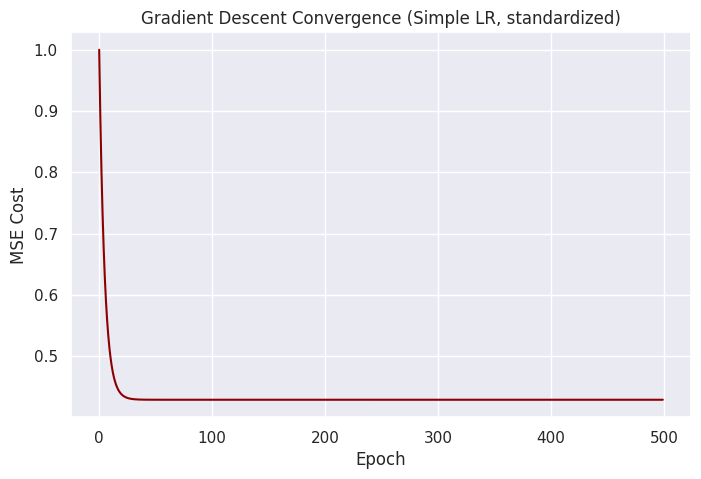

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(cost_log, color="darkred")
plt.xlabel("Epoch")
plt.ylabel("MSE Cost")
plt.title("Gradient Descent Convergence (Simple LR, standardized)")
plt.show()

The cost curve drops sharply in the first few dozen epochs and then flattens out —
a sign the weight and bias have converged close to their optimal values.

---
## Part H: Train vs Test Scores (Bias–Variance Check)

In [ ]:
model_lookup = {
    "Simple LR": (lr_simple, X_train_sim, y_train_sim, X_test_sim, y_test_sim),
    "Multiple LR": (lr_multi, X_train_full, y_train_full, X_test_full, y_test_full),
    "Polynomial LR": (lr_poly, X_train_poly, y_train_poly, X_test_poly, y_test_poly),
}

train_test_rows = []
for name, (model, xtr, ytr, xte, yte) in model_lookup.items():
    train_score = model.score(xtr, ytr)
    test_score = model.score(xte, yte)
    train_test_rows.append({"Model": name, "Train R2": train_score, "Test R2": test_score,
                             "Gap": train_score - test_score})
    print(f"{name:15s} | Train R2 = {train_score:.4f} | Test R2 = {test_score:.4f}")

pd.DataFrame(train_test_rows)

Simple LR       | Train R2 = 0.5723 | Test R2 = 0.5625
Multiple LR     | Train R2 = 0.9247 | Test R2 = 0.9178
Polynomial LR   | Train R2 = 0.9685 | Test R2 = 0.9664


,Model,Train R2,Test R2,Gap
0,Simple LR,0.572307,0.562520,0.009788
1,Multiple LR,0.924722,0.917761,0.006961
2,Polynomial LR,0.968456,0.966436,0.002020


A small gap between train and test R² means the model generalizes well. A large gap
(train much higher than test) would be the signature of overfitting; both scores
being low together would signal underfitting instead.

---
## Part I: Conclusions

1. **Multiple Linear Regression clearly outperforms Simple Linear Regression** —
   using all the available property features instead of area alone captures far more
   of what actually drives price.
2. **Polynomial Regression edges out Multiple Linear Regression** on R², since it can
   model curved/interaction effects between features that a straight-line model misses.
3. **Gradient Descent successfully learned the same relationship** as the closed-form
   solution once the input was standardized — confirming the optimization approach works.
4. **Overfitting would show up as a widening train–test gap**, especially if
   polynomial degree were pushed higher without more data to support it.
5. **Taking R², Adjusted R², and RMSE together, Multiple/Polynomial Regression are the
   strongest candidates** for a real house-price prediction tool, balancing accuracy
   with the ability to explain *why* a price was predicted — an important factor for a
   real estate analytics business.